Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating 3‑class split (5c_front, 5c_back, 25c)...
Found 168 5c front, 159 5c back
Found 318 25c images
5c_front: total=168 | train=117 | val=33 | test=18
5c_back: total=159 | train=111 | val=31 | test=17
25c: total=318 | train=222 | val=63 | test=33
Found 450 files belonging to 3 classes.
Found 127 files belonging to 3 classes.
Found 68 files belonging to 3 classes.
Classes: ['25c', '5c_back', '5c_front']
Class weights: {0: np.float64(0.6756756756756757), 1: np.float64(1.3513513513513513), 2: np.float64(1.2820512820512822)}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.3844 - loss: 1.3108 - val_accuracy: 0.2598 - val_loss: 1.3348 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.3444 - loss: 1.1782 - val_accuracy: 0.4331 - val_loss: 1.1578 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.4044 - loss: 1.1085 - val_accuracy: 0.4961 - val_loss: 1.2253 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 0.3444 - loss: 1.0908 - val_accuracy: 0.5039 - val_loss: 1.0151 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.3378 - loss: 1.1031 - val_accuracy: 0.4961 - val_loss: 0.9985 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.3444 - loss: 1.0990 - val_accuracy: 0.5512 - val_loss: 0.9138 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.4756 - loss: 1.0807 - val_accuracy: 

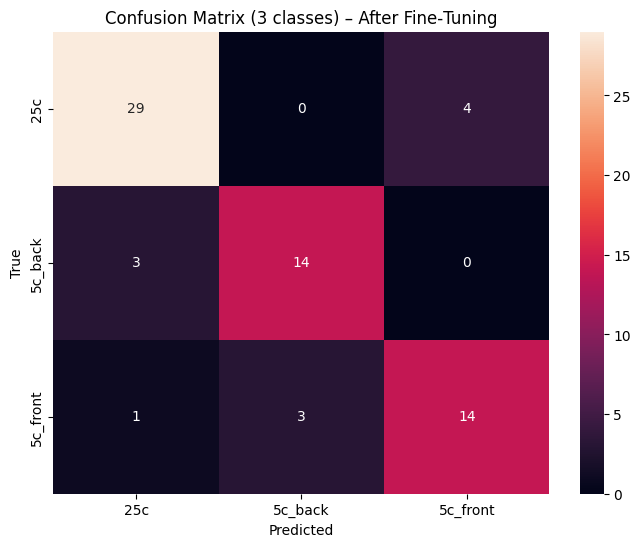


Per-class accuracy after fine‑tuning:
25c: 87.88%
5c_back: 82.35%
5c_front: 77.78%
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 918ms/step - accuracy: 0.8382 - loss: 0.6493

Overall test accuracy: 0.8382

Total 5c_back test samples: 17
Misclassified 5c_back: 3


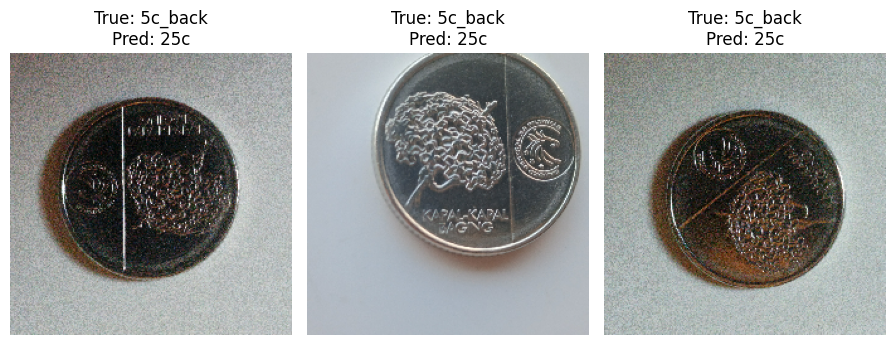

Improved model saved.


In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import drive, files
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

drive.mount('/content/drive')

# ============================================
# 1. CONFIGURATION
# ============================================
DATASET_ROOT = "/content/drive/MyDrive/Peso Centavo Dataset"
SPLIT_DIR = "/content/drive/MyDrive/dataset_split_3class"
CLASS_MAPPING = {
    '5c_front': '5c',
    '5c_back': '5c',
    '25c': '25c'
}
IMG_SIZE = 224
BATCH_SIZE = 32

# ============================================
# 2. CREATE 3‑CLASS SPLIT (5c_front, 5c_back, 25c)
# ============================================
print("Creating 3‑class split (5c_front, 5c_back, 25c)...")

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(SPLIT_DIR, split), exist_ok=True)

# Process 5c folder
five_c_path = os.path.join(DATASET_ROOT, "5c")
if not os.path.isdir(five_c_path):
    raise FileNotFoundError("5c folder not found")

images_5c = [f for f in os.listdir(five_c_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
front_images = [f for f in images_5c if 'front' in f.lower()]
back_images = [f for f in images_5c if 'back' in f.lower()]
print(f"Found {len(front_images)} 5c front, {len(back_images)} 5c back")

# 25c images
twentyfive_c_path = os.path.join(DATASET_ROOT, "25c")
if not os.path.isdir(twentyfive_c_path):
    raise FileNotFoundError("25c folder not found")
images_25c = [f for f in os.listdir(twentyfive_c_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
print(f"Found {len(images_25c)} 25c images")

def split_and_copy(file_list, src_dir, class_name, dest_base):
    random.shuffle(file_list)
    n_train = int(len(file_list) * 0.7)
    n_val = int(len(file_list) * 0.2)
    splits = {
        'train': file_list[:n_train],
        'val': file_list[n_train:n_train+n_val],
        'test': file_list[n_train+n_val:]
    }
    for split_name, imgs in splits.items():
        out_dir = os.path.join(dest_base, split_name, class_name)
        os.makedirs(out_dir, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(src_dir, img), os.path.join(out_dir, img))
    return len(file_list), n_train, n_val, len(file_list)-n_train-n_val

n_front, train_f, val_f, test_f = split_and_copy(front_images, five_c_path, "5c_front", SPLIT_DIR)
n_back, train_b, val_b, test_b = split_and_copy(back_images, five_c_path, "5c_back", SPLIT_DIR)
n_25c, train_25, val_25, test_25 = split_and_copy(images_25c, twentyfive_c_path, "25c", SPLIT_DIR)

print(f"5c_front: total={n_front} | train={train_f} | val={val_f} | test={test_f}")
print(f"5c_back: total={n_back} | train={train_b} | val={val_b} | test={test_b}")
print(f"25c: total={n_25c} | train={train_25} | val={val_25} | test={test_25}")

# ============================================
# 3. LOAD DATA (3 classes)
# ============================================
train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
val_raw = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
test_raw = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_raw.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# ============================================
# 4. STRONGER DATA AUGMENTATION
# ============================================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),          # increased from 0.15
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.2),         # new
    layers.RandomTranslation(0.1, 0.1),   # new
])

def preprocess_train(x, y):
    x = preprocess_input(x)
    x = data_aug(x, training=True)
    return x, y

train_data = train_raw.map(preprocess_train).prefetch(tf.data.AUTOTUNE)
val_data = val_raw.map(lambda x,y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_data = test_raw.map(lambda x,y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

# ============================================
# 5. COMPUTE CLASS WEIGHTS (to balance training)
# ============================================
train_labels = []
for _, labels in train_raw:
    train_labels.extend(np.argmax(labels.numpy(), axis=1))
train_labels = np.array(train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# ============================================
# 6. BUILD MODEL (frozen MobileNetV2)
# ============================================
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ============================================
# 7. INITIAL TRAINING (frozen base + class weights)
# ============================================
callbacks = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ============================================
# 8. FINE-TUNE TOP LAYERS OF MOBILENETV2
# ============================================
base.trainable = True
# Freeze all layers except the last 30
for layer in base.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = 30 + fine_tune_epochs

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ============================================
# 9. EVALUATE ON TEST SET (per class)
# ============================================
# Get true labels and predictions
y_true = []
y_pred = []
test_images_list = []   # for visual inspection
for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    test_images_list.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
test_images_np = np.array(test_images_list)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (3 classes) – After Fine‑Tuning")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Per-class accuracy
print("\nPer-class accuracy after fine‑tuning:")
for i, name in enumerate(class_names):
    tp = cm[i,i]
    total = np.sum(cm[i,:])
    acc = tp / total if total > 0 else 0
    print(f"{name}: {acc:.2%}")

# Overall accuracy
test_loss, test_acc = model.evaluate(test_data)
print(f"\nOverall test accuracy: {test_acc:.4f}")

# ============================================
# 10. VISUALIZE MISCLASSIFIED 5c_back IMAGES
# ============================================
back_idx = class_names.index('5c_back')
mis_back = np.where((y_true == back_idx) & (y_pred != back_idx))[0]

print(f"\nTotal 5c_back test samples: {np.sum(y_true == back_idx)}")
print(f"Misclassified 5c_back: {len(mis_back)}")

if len(mis_back) > 0:
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(mis_back[:5]):
        img = (test_images_np[idx] + 1) / 2  # denormalize from [-1,1] to [0,1]
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified 5c_back images found!")

# ============================================
# 11. SAVE MODEL
# ============================================
model.save("/content/drive/MyDrive/coin_model_3class_improved.h5")
print("Improved model saved.")

# ============================================
# 12. PREDICTION FUNCTION (same as original)
# ============================================
def predict_coin():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img = Image.open(filename).convert('RGB')
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        x = np.expand_dims(preprocess_input(np.array(img_resized)), axis=0)
        pred = model.predict(x, verbose=0)[0]
        idx = np.argmax(pred)
        confidence = pred[idx]
        raw_label = class_names[idx]
        if raw_label.startswith('5c'):
            final_label = '5c'
        else:
            final_label = '25c'
        print(f"Raw prediction: {raw_label} ({confidence:.2%}) -> Final: {final_label}")

        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title("Uploaded Coin")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.bar(class_names, pred, color=['skyblue', 'lightcoral', 'lightgreen'])
        plt.title(f"Raw: {raw_label}\nFinal: {final_label}")
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()

Saving images (5).jpg to images (5).jpg
Raw prediction: 5c_front (63.74%) -> Final: 5c


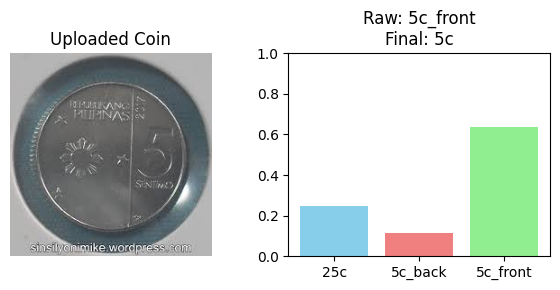

In [ ]:
# ============================================
# 13. ASK USER FOR TEST
# ============================================
predict_coin()